In [1]:
import sys
sys.path.append('../src')

from dataset import DRDataset
from torch.utils.data import DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import torch

%matplotlib inline

print("Imports successful!")

Imports successful!


In [2]:
# Create dataset
data_dir = Path('../data/raw/idrid')

dataset = DRDataset(
    image_dir=data_dir,
    csv_file=None,
    target_size=512
)

print(f"Dataset size: {len(dataset)} images")

No labels file provided - using dummy labels
Found 1113 images in ../data/raw/idrid
Dataset size: 1113 images


In [3]:
# Create DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=16,      # Load 16 images at a time
    shuffle=True,       # Shuffle for training
    num_workers=0       # 0 for MacBook (avoids issues)
)

print(f"DataLoader created!")
print(f"Number of batches: {len(dataloader)}")
print(f"Batch size: {dataloader.batch_size}")

DataLoader created!
Number of batches: 70
Batch size: 16


In [4]:
images, labels = next(iter(dataloader))

print(f"Batch of images shape: {images.shape}")  # Should be [16, 3, 512, 512]
print(f"Batch of labels shape: {labels.shape}")  # Should be [16]
print(f"Images dtype: {images.dtype}")
print(f"Labels dtype: {labels.dtype}")

Batch of images shape: torch.Size([16, 3, 512, 512])
Batch of labels shape: torch.Size([16])
Images dtype: torch.float32
Labels dtype: torch.int64


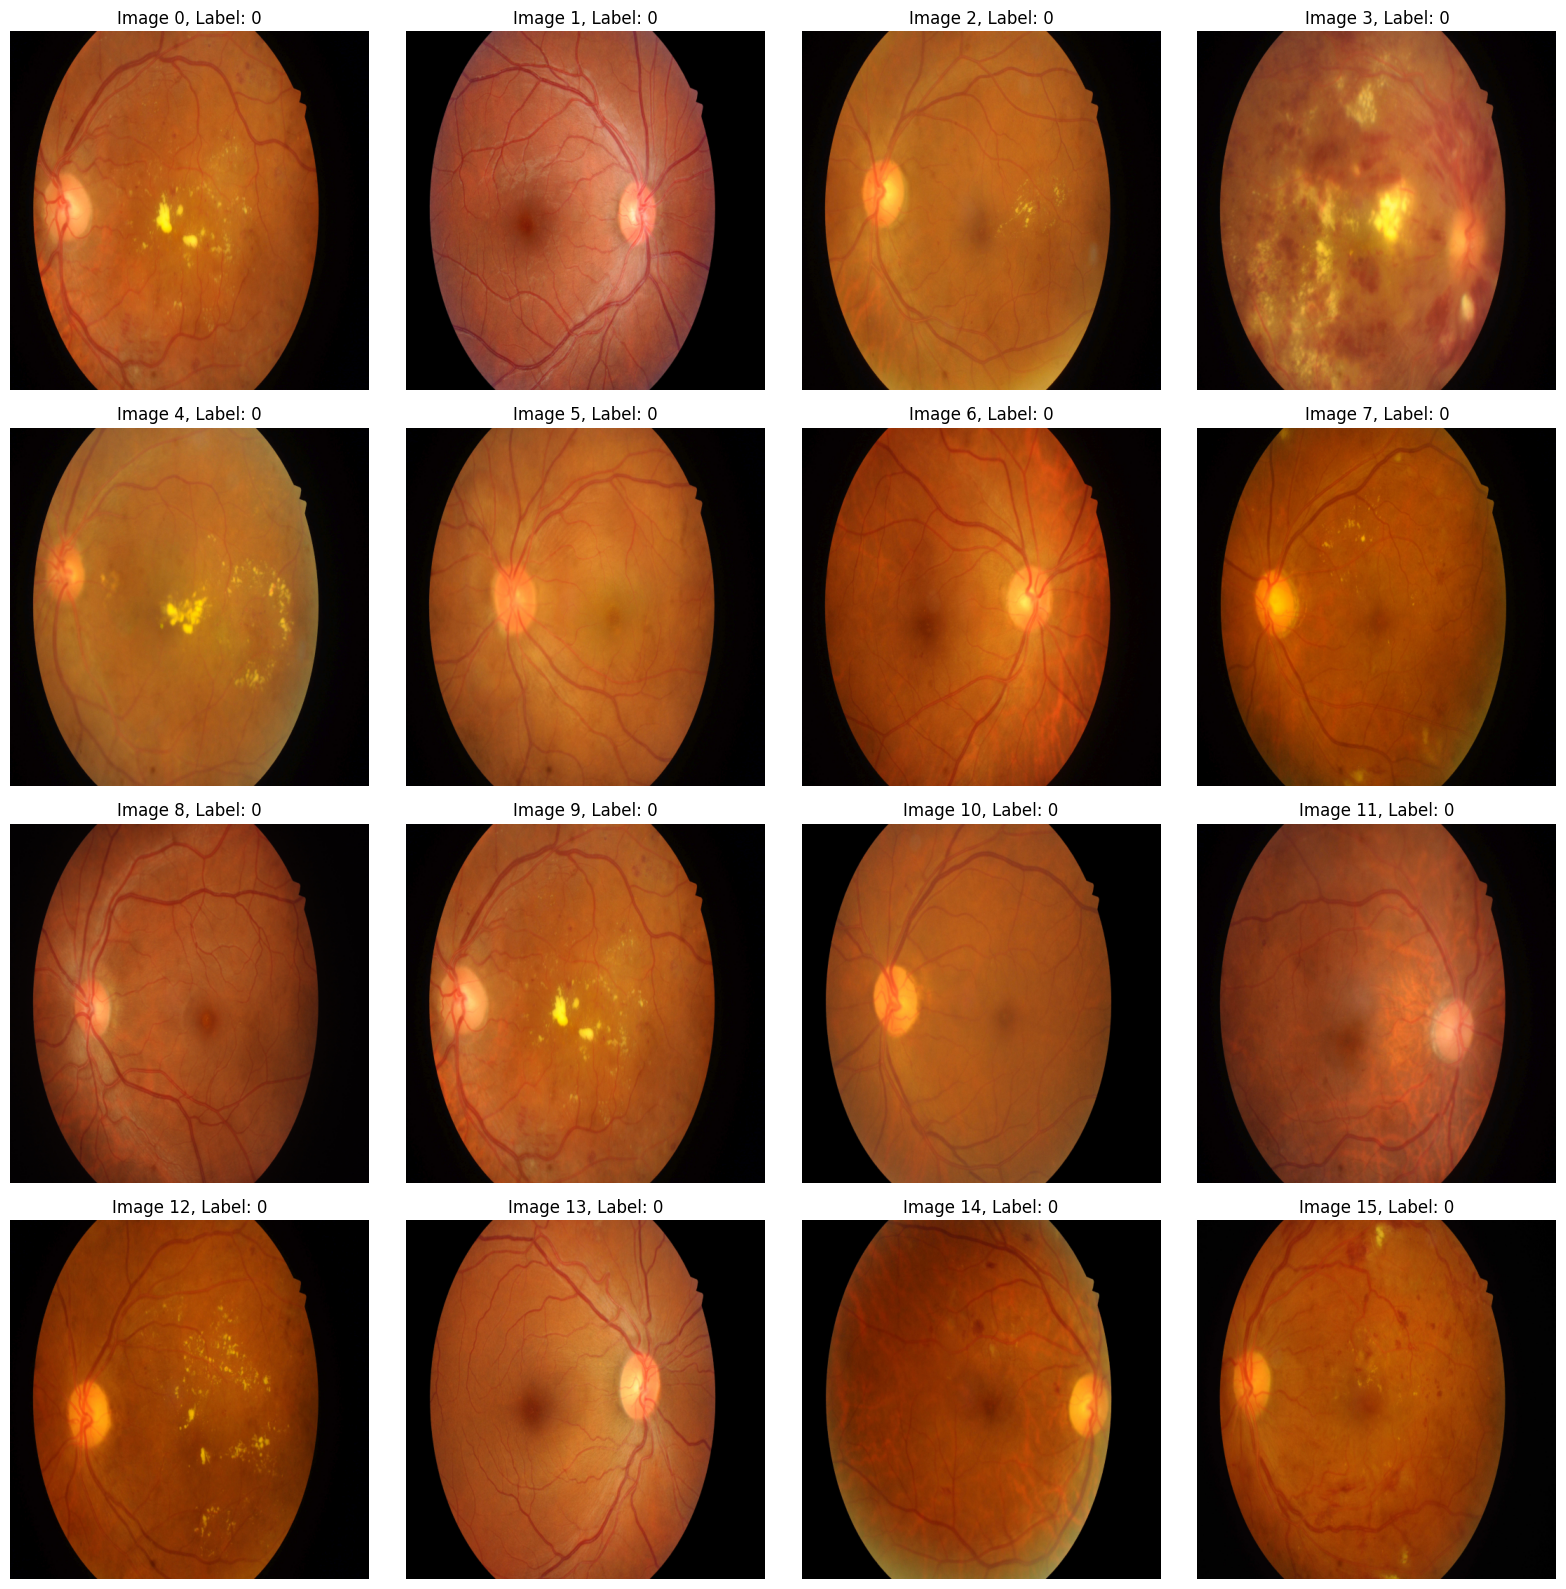

Successfully loaded and displayed one batch of 16 images!


In [6]:
# Display first batch
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx in range(16):
    # Get image from batch
    img = images[idx]
    label = labels[idx]
    
    # Convert from (C, H, W) to (H, W, C) for display
    img_np = img.permute(1, 2, 0).numpy()
    
    # Display
    axes[idx].imshow(img_np)
    axes[idx].set_title(f"Image {idx}, Label: {label.item()}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Successfully loaded and displayed one batch of 16 images!")

In [7]:
# Iterate through a few batches
print("Testing batch iteration...")

for batch_idx, (images, labels) in enumerate(dataloader):
    print(f"Batch {batch_idx}: Images {images.shape}, Labels {labels.shape}")
    
    # Only test first 3 batches
    if batch_idx >= 2:
        break

print("\nDataLoader can iterate through batches!")

Testing batch iteration...
Batch 0: Images torch.Size([16, 3, 512, 512]), Labels torch.Size([16])
Batch 1: Images torch.Size([16, 3, 512, 512]), Labels torch.Size([16])
Batch 2: Images torch.Size([16, 3, 512, 512]), Labels torch.Size([16])

DataLoader can iterate through batches!


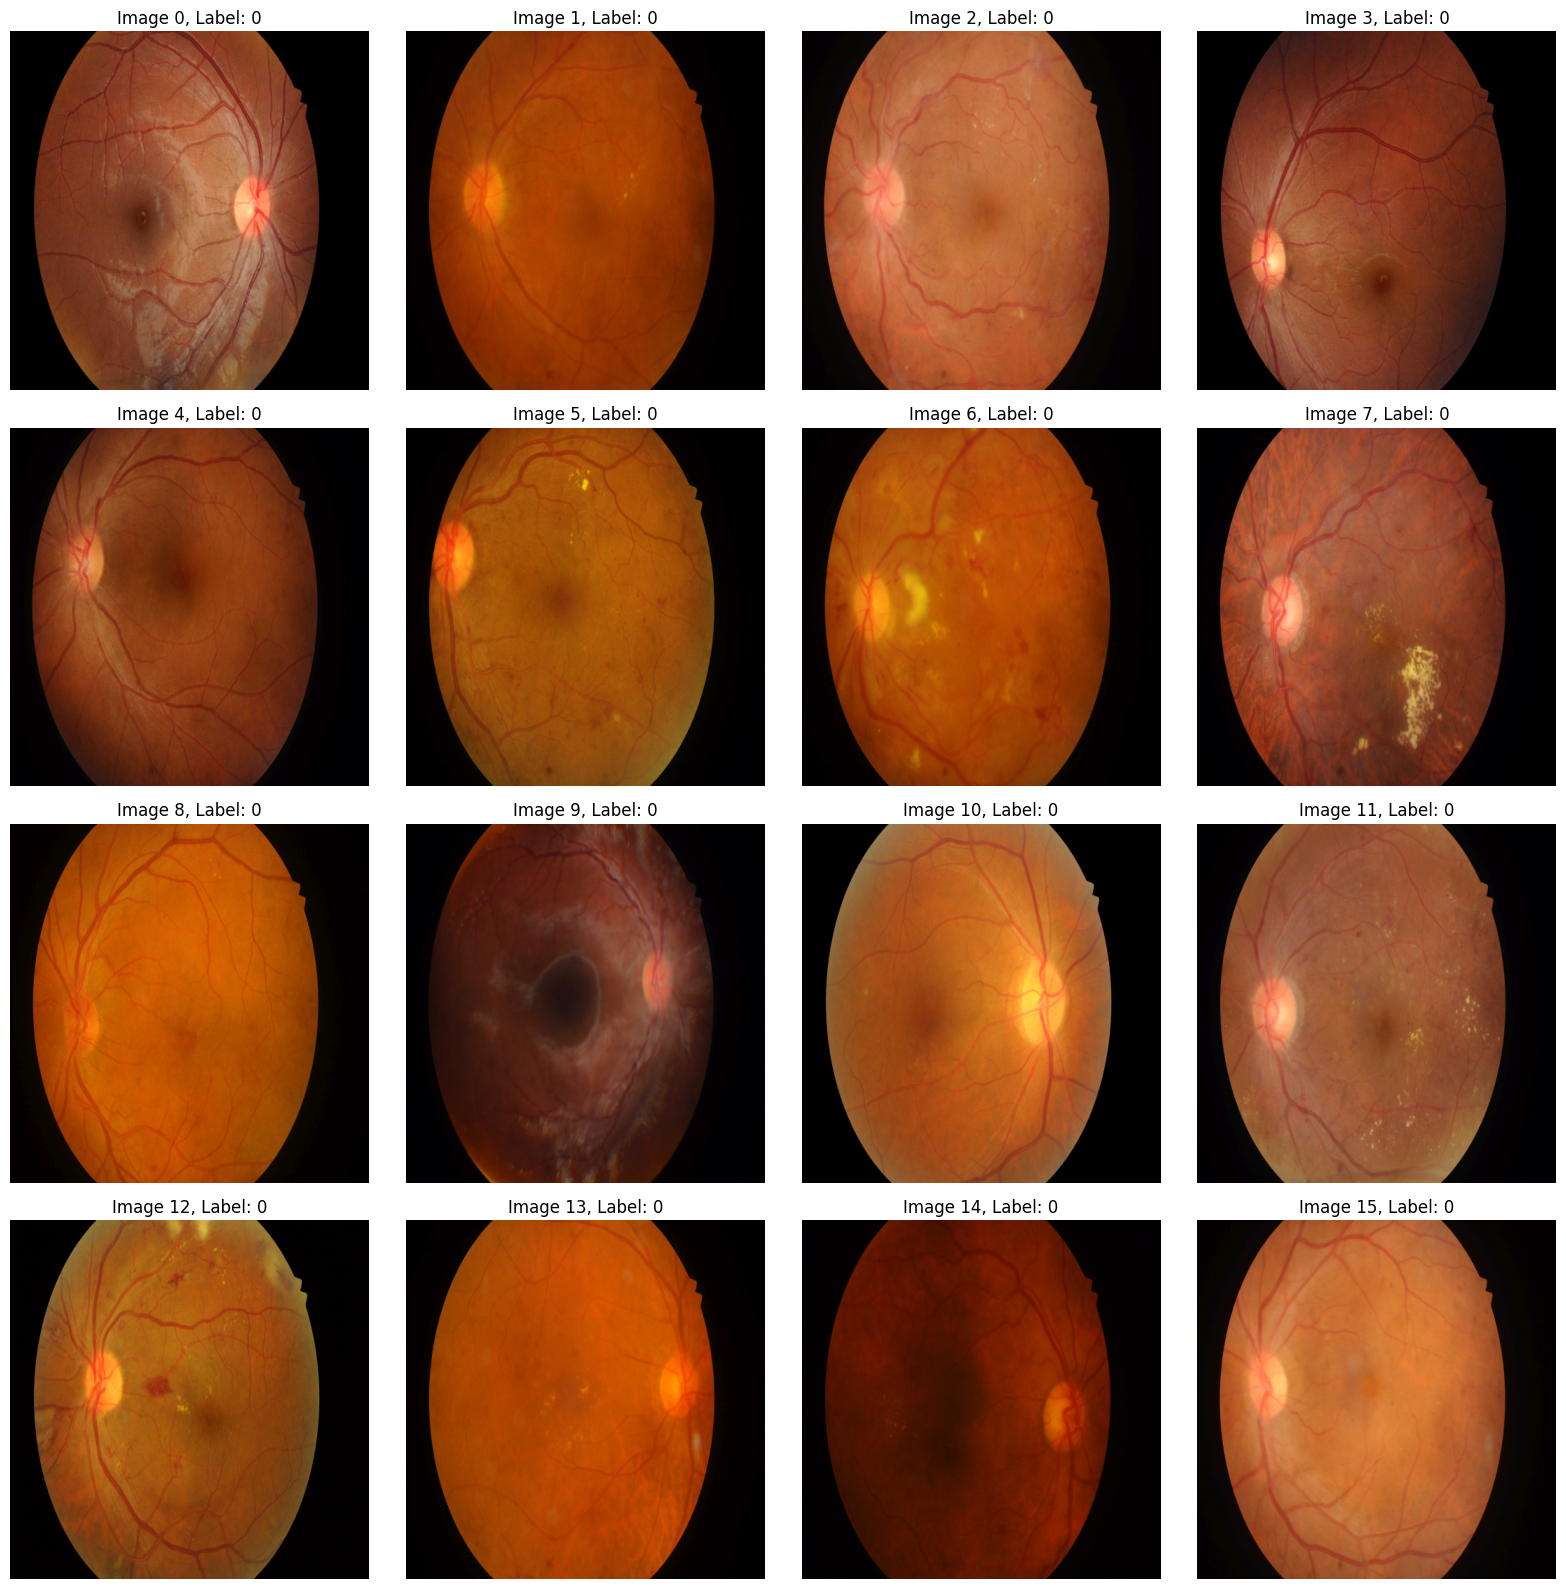

Successfully loaded and displayed one batch of 16 images!


In [8]:
# Display first batch
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx in range(16):
    # Get image from batch
    img = images[idx]
    label = labels[idx]
    
    # Convert from (C, H, W) to (H, W, C) for display
    img_np = img.permute(1, 2, 0).numpy()
    
    # Display
    axes[idx].imshow(img_np)
    axes[idx].set_title(f"Image {idx}, Label: {label.item()}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Successfully loaded and displayed one batch of 16 images!")

In [9]:
# Iterate through a few batches
print("Testing batch iteration...")

for batch_idx, (images, labels) in enumerate(dataloader):
    print(f"Batch {batch_idx}: Images {images.shape}, Labels {labels.shape}")
    
    # Only test first 3 batches
    if batch_idx >= 2:
        break

print("\nDataLoader can iterate through batches!")

Testing batch iteration...
Batch 0: Images torch.Size([16, 3, 512, 512]), Labels torch.Size([16])
Batch 1: Images torch.Size([16, 3, 512, 512]), Labels torch.Size([16])
Batch 2: Images torch.Size([16, 3, 512, 512]), Labels torch.Size([16])

DataLoader can iterate through batches!


In [10]:
print("="*60)
print("DATALOADER SUMMARY")
print("="*60)
print(f" Dataset: {len(dataset)} images")
print(f" Batch size: {dataloader.batch_size}")
print(f" Number of batches: {len(dataloader)}")
print(f" Shuffle: True")
print(f" Image shape per batch: [16, 3, 512, 512]")
print(f"Ready for model training!")
print("="*60)

DATALOADER SUMMARY
 Dataset: 1113 images
 Batch size: 16
 Number of batches: 70
 Shuffle: True
 Image shape per batch: [16, 3, 512, 512]
Ready for model training!
